# B31MV — Lab 5: 3D Point Cloud Processing and ICP Registration

**Course:** B31MV Machine Vision · Heriot-Watt University · Spring 2025
**Author:** Umut Akti

---

## Overview

This notebook covers the 3D reconstruction pipeline using **Open3D**, extended with
**Iterative Closest Point (ICP) registration** — the algorithm that aligns overlapping
point cloud scans, a core operation in SLAM, Structure from Motion, and robotic mapping.

```
Triangle Mesh  (MonkeyModel)
    └─► Point Cloud  (uniform sampling)
            ├─► Statistical Outlier Removal
            └─► Voxel Grid Downsampling
                    └─► Normal Estimation
                            └─► Poisson Surface Reconstruction
                                    └─► ICP Registration  ◄── main focus
                                            (align two partial scans)
```


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import open3d as o3d

print(f"Open3D version: {o3d.__version__}")
np.random.seed(42)

# ── Visualisation helpers ─────────────────────────────────────────────────────

def pcd_scatter(ax, pcd, title='', cmap='viridis', s=1.0, alpha=0.6):
    """Scatter-plot a point cloud coloured by Z height."""
    pts = np.asarray(pcd.points)
    if len(pts) == 0:
        ax.set_title(f'{title}\n(empty)'); return
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2],
               c=pts[:, 2], cmap=cmap, s=s, alpha=alpha, linewidths=0)
    ax.set_title(f'{title}\n({len(pts):,} pts)', fontsize=9)
    ax.set_axis_off()


def mesh_scatter(ax, mesh, title='', cmap='plasma', s=0.5):
    """Scatter-plot mesh vertices coloured by Z."""
    verts = np.asarray(mesh.vertices)
    tris  = np.asarray(mesh.triangles)
    if len(verts) == 0:
        ax.set_title(f'{title}\n(empty)'); return
    ax.scatter(verts[:, 0], verts[:, 1], verts[:, 2],
               c=verts[:, 2], cmap=cmap, s=s, alpha=0.6, linewidths=0)
    ax.set_title(
        f'{title}\n({len(verts):,} verts | {len(tris):,} tris)', fontsize=9)
    ax.set_axis_off()


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Open3D version: 0.19.0


---
## Part 1 — Mesh Loading and Point Cloud Preprocessing

### 1.1  Load the Monkey Model

`o3d.data.MonkeyModel()` downloads (once) and provides a path to the
Blender Suzanne `.obj` file — Open3D's standard test asset for 3D reconstruction demos.


[Open3D INFO] Downloading https://github.com/isl-org/open3d_downloads/releases/download/20220301-data/MonkeyModel.zip
[Open3D INFO] Downloaded to C:\Users\Umut Akti/open3d_data/download/MonkeyModel/MonkeyModel.zip
[Open3D INFO] Created directory C:\Users\Umut Akti/open3d_data/extract/MonkeyModel.
[Open3D INFO] Extracting C:\Users\Umut Akti/open3d_data/download/MonkeyModel/MonkeyModel.zip.
[Open3D INFO] Extracted to C:\Users\Umut Akti/open3d_data/extract/MonkeyModel.
Vertices   : 9,908
Triangles  : 15,744
Watertight : False


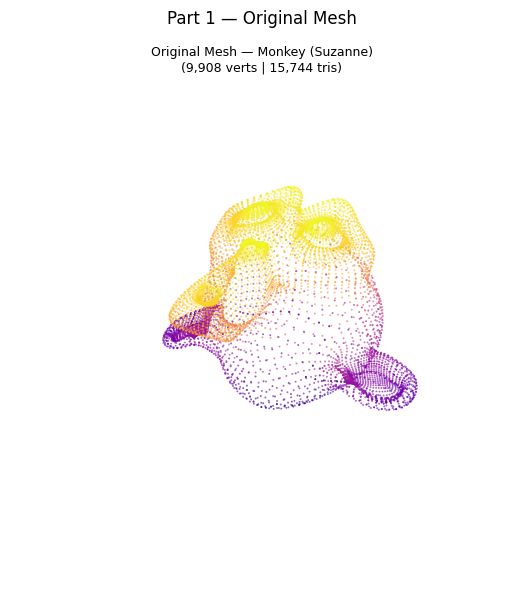

In [3]:
# ── Load mesh ─────────────────────────────────────────────────────────────────
dataset    = o3d.data.MonkeyModel()
mesh       = o3d.io.read_triangle_mesh(dataset.path)
mesh.compute_vertex_normals()

# Rotate upright — Blender exports Suzanne with her face along +Z ("staring at ceiling").
# A -90 deg rotation around X tips the face to +Y and the crown to +Z,
# so she stands upright and faces the viewer in the scatter plots.
mesh.rotate(mesh.get_rotation_matrix_from_xyz((-np.pi / 2, 0, 0)),
            center=mesh.get_center())

verts = np.asarray(mesh.vertices)
tris  = np.asarray(mesh.triangles)

print(f"Vertices   : {len(verts):,}")
print(f"Triangles  : {len(tris):,}")
print(f"Watertight : {mesh.is_watertight()}")

fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection='3d')
mesh_scatter(ax, mesh, title='Original Mesh — Monkey (Suzanne)', cmap='plasma', s=2.0)
plt.suptitle('Part 1 — Original Mesh', fontsize=12)
plt.tight_layout()
plt.show()


### 1.2  Uniform Point Cloud Sampling

`sample_points_uniformly` places points proportional to triangle area.
50 k points gives a dense enough cloud for Poisson reconstruction later.


Sampled 50,000 points from mesh


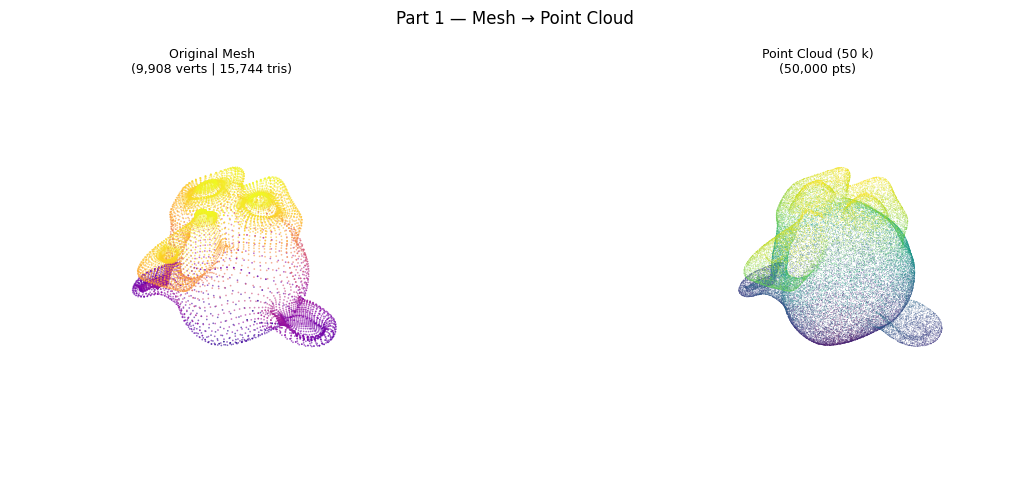

In [4]:
N_SAMPLES   = 50_000
pcd_uniform = mesh.sample_points_uniformly(number_of_points=N_SAMPLES)
print(f"Sampled {len(pcd_uniform.points):,} points from mesh")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), subplot_kw={'projection': '3d'})
mesh_scatter(axes[0], mesh,        title='Original Mesh',     cmap='plasma', s=1.5)
pcd_scatter (axes[1], pcd_uniform, title='Point Cloud (50 k)', cmap='viridis', s=0.3)
plt.suptitle('Part 1 — Mesh → Point Cloud', fontsize=12)
plt.tight_layout()
plt.show()


### 1.3  Statistical Outlier Removal (SOR)

Each point's mean distance to its *k* nearest neighbours is computed.
Points further than `std_ratio × σ` from the global mean are flagged as outliers.

Gaussian noise + 500 hard outliers are injected first to simulate a real depth sensor.


Before SOR : 50,000
After  SOR : 49,602   (removed 398)


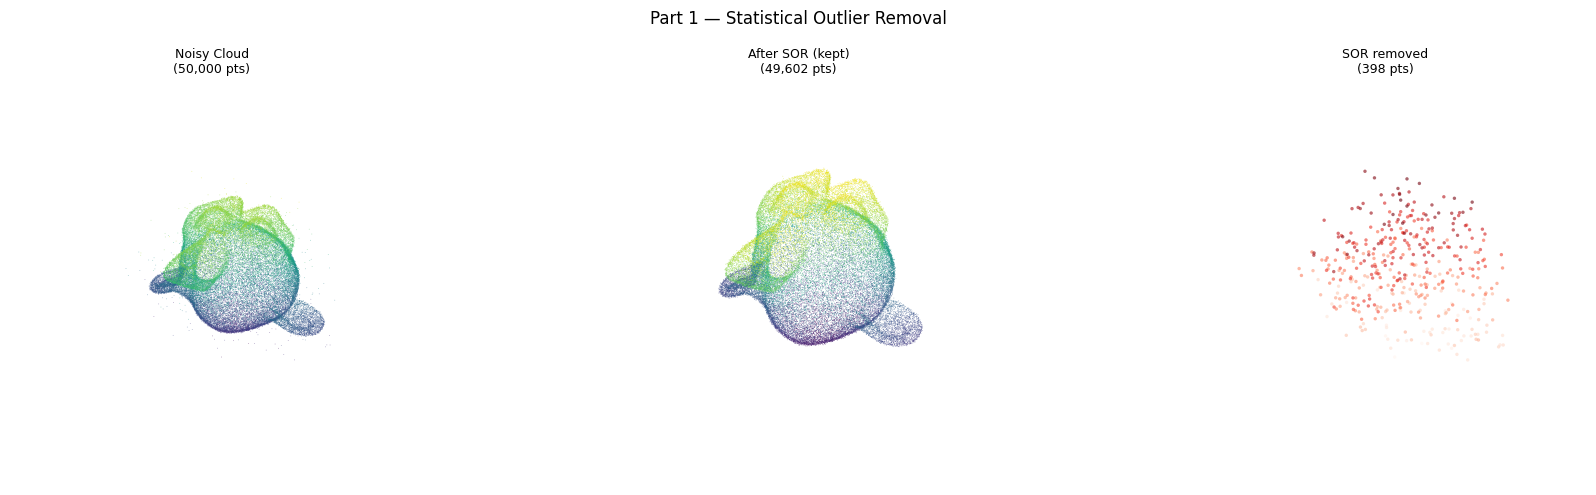

In [5]:
# ── Inject noise ──────────────────────────────────────────────────────────────
pcd_noisy = o3d.geometry.PointCloud(pcd_uniform)
pts = np.asarray(pcd_noisy.points).copy()

pts += np.random.normal(0, 0.008, pts.shape)                    # mild Gaussian noise

hard_idx = np.random.choice(len(pts), 500, replace=False)       # 500 hard outliers
pts[hard_idx] += np.random.uniform(-0.4, 0.4, (500, 3))

pcd_noisy.points = o3d.utility.Vector3dVector(pts)

# ── Apply SOR ─────────────────────────────────────────────────────────────────
pcd_sor, sor_idx = pcd_noisy.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)

n_removed   = len(pcd_noisy.points) - len(pcd_sor.points)
removed_idx = np.setdiff1d(np.arange(len(pcd_noisy.points)),
                            np.asarray(sor_idx)).tolist()
pcd_removed = pcd_noisy.select_by_index(removed_idx)

print(f"Before SOR : {len(pcd_noisy.points):,}")
print(f"After  SOR : {len(pcd_sor.points):,}   (removed {n_removed:,})")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={'projection': '3d'})
pcd_scatter(axes[0], pcd_noisy,   title='Noisy Cloud',      cmap='viridis', s=0.3)
pcd_scatter(axes[1], pcd_sor,     title='After SOR (kept)', cmap='viridis', s=0.3)
pcd_scatter(axes[2], pcd_removed, title='SOR removed',      cmap='Reds',    s=6.0)
plt.suptitle('Part 1 — Statistical Outlier Removal', fontsize=12)
plt.tight_layout()
plt.show()


### 1.4  Voxel Grid Downsampling

Space is divided into cubes of side `voxel_size`. All points in each cube are replaced
by their centroid — producing uniform spatial coverage at lower point count.


Before voxel DS : 49,602
After  voxel DS : 6,687  (7.4× compression)


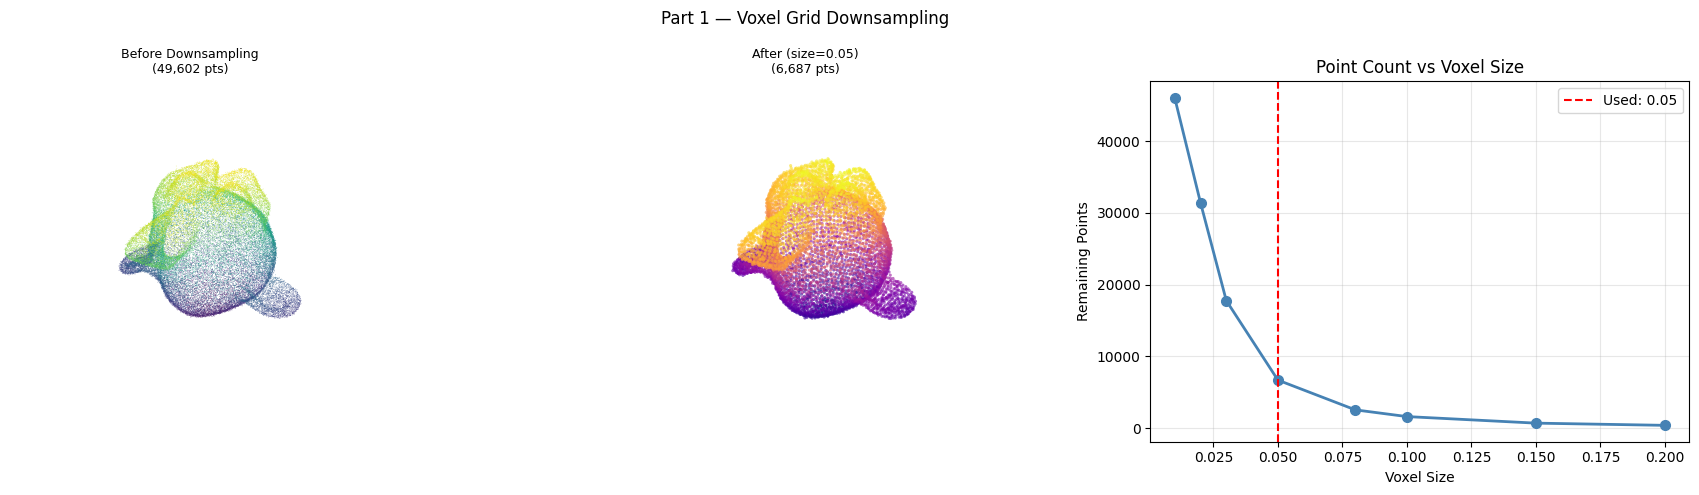

In [6]:
VOXEL_SIZE = 0.05
pcd_voxel  = pcd_sor.voxel_down_sample(voxel_size=VOXEL_SIZE)

print(f"Before voxel DS : {len(pcd_sor.points):,}")
print(f"After  voxel DS : {len(pcd_voxel.points):,}  "
      f"({len(pcd_sor.points)/len(pcd_voxel.points):.1f}× compression)")

# ── Sensitivity: voxel size vs point count ────────────────────────────────────
sizes  = [0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20]
counts = [len(pcd_sor.voxel_down_sample(v).points) for v in sizes]

fig = plt.figure(figsize=(18, 5))
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax3 = fig.add_subplot(1, 3, 3)

pcd_scatter(ax1, pcd_sor,   title='Before Downsampling',       cmap='viridis', s=0.3)
pcd_scatter(ax2, pcd_voxel, title=f'After (size={VOXEL_SIZE})', cmap='plasma',  s=5.0)

ax3.plot(sizes, counts, 'o-', color='steelblue', linewidth=2, markersize=7)
ax3.axvline(VOXEL_SIZE, color='red', linestyle='--',
            label=f'Used: {VOXEL_SIZE}')
ax3.set_xlabel('Voxel Size')
ax3.set_ylabel('Remaining Points')
ax3.set_title('Point Count vs Voxel Size')
ax3.legend(); ax3.grid(True, alpha=0.3)

plt.suptitle('Part 1 — Voxel Grid Downsampling', fontsize=12)
plt.tight_layout()
plt.show()


---
## Part 2 — Surface Normal Estimation and Poisson Reconstruction

### 2.1  Normal Estimation

A local plane is fitted to each point's *k* nearest neighbours (PCA).
The smallest-eigenvalue eigenvector = surface normal.

`orient_normals_consistent_tangent_plane` propagates outward orientation
through a minimum spanning tree of the neighbourhood graph.


Normals estimated : True
Sample L2 norms   : 1.00000, 1.00000, 1.00000, 1.00000, 1.00000  (≈ 1.0 each)


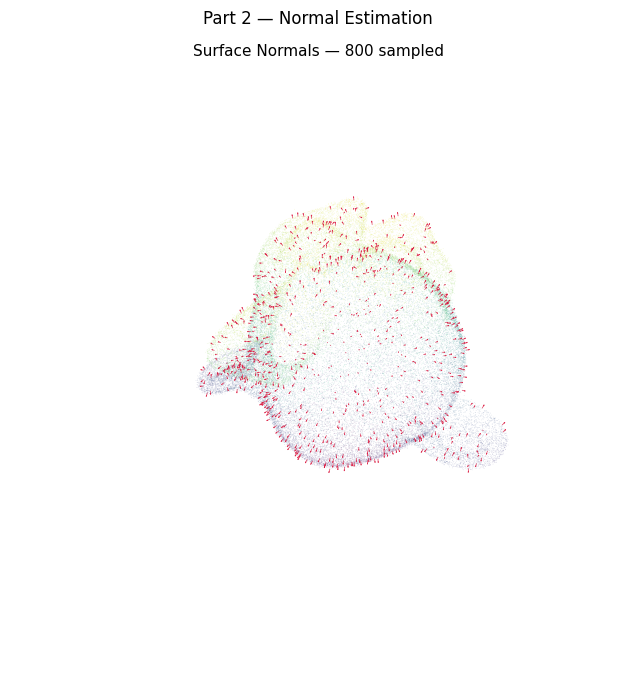

In [7]:
pcd_recon = o3d.geometry.PointCloud(pcd_sor)

pcd_recon.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
pcd_recon.orient_normals_consistent_tangent_plane(k=30)

normals = np.asarray(pcd_recon.normals)
pts_r   = np.asarray(pcd_recon.points)

print(f"Normals estimated : {pcd_recon.has_normals()}")
norms = np.linalg.norm(normals[:5], axis=1)
print(f"Sample L2 norms   : {', '.join(f'{v:.5f}' for v in norms)}  (≈ 1.0 each)")

# ── Quiver plot — 800 sampled normal arrows ────────────────────────────────────
idx     = np.random.choice(len(pts_r), 800, replace=False)
scale   = 0.025

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')
ax.scatter(pts_r[:, 0], pts_r[:, 1], pts_r[:, 2],
           c=pts_r[:, 2], cmap='viridis', s=0.3, alpha=0.2, linewidths=0)
ax.quiver(pts_r[idx, 0], pts_r[idx, 1], pts_r[idx, 2],
          normals[idx, 0]*scale, normals[idx, 1]*scale, normals[idx, 2]*scale,
          color='crimson', linewidth=0.5, alpha=0.8, arrow_length_ratio=0.4)
ax.set_title('Surface Normals — 800 sampled', fontsize=11)
ax.set_axis_off()
plt.suptitle('Part 2 — Normal Estimation', fontsize=12)
plt.tight_layout()
plt.show()


### 2.2  Poisson Surface Reconstruction

Solves a global optimisation: find the indicator function whose gradient
best matches the oriented normals. The zero-isosurface = reconstructed mesh.

`depth` controls octree resolution (8–9 = good balance of detail vs speed).
The returned `densities` array flags how well-supported each vertex is —
low-density vertices are artefacts and removed by thresholding.


Running Poisson (depth=9) ...
Vertices   : 128,782
Triangles  : 257,480
Watertight : False
Density    : min=6.28  mean=7.22  max=8.03

After density filter (10th pct = 6.961)
  Vertices  : 115,903
  Triangles : 219,921


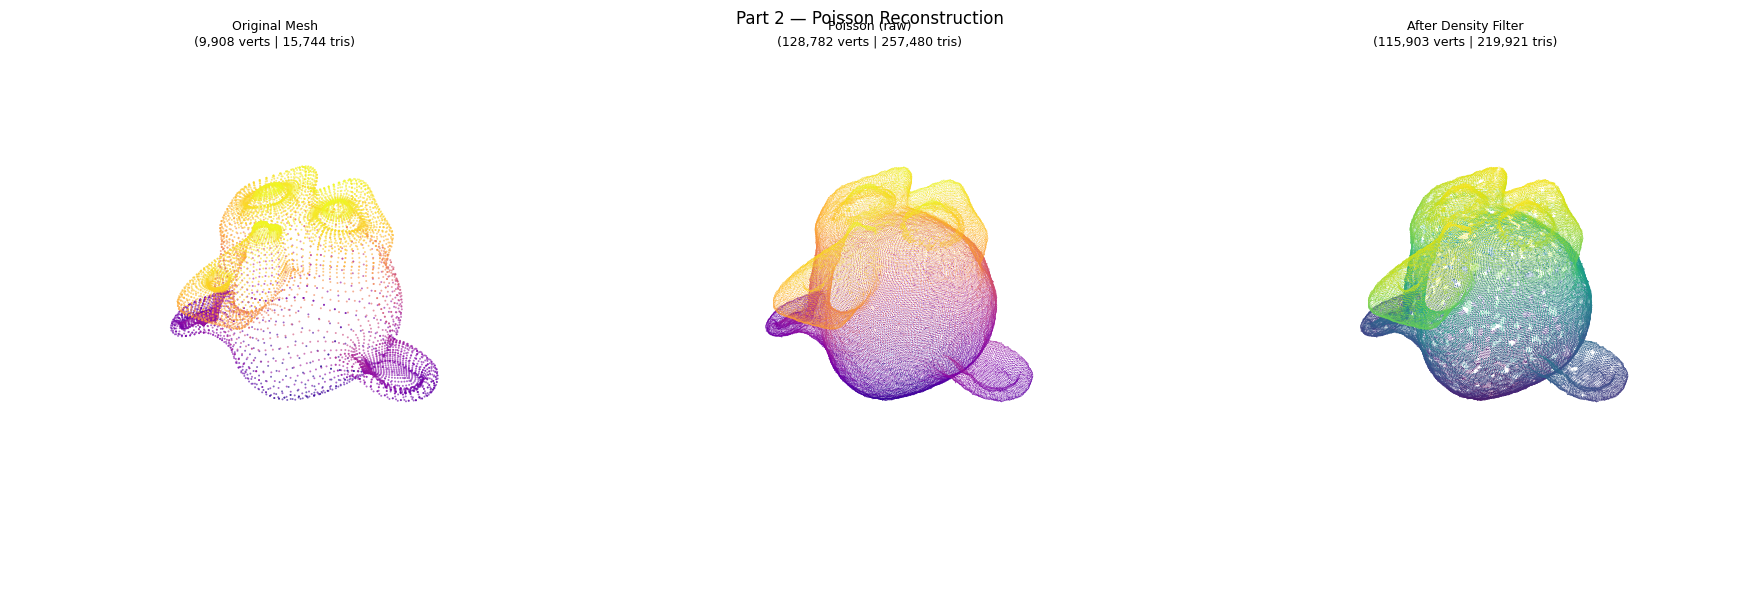

In [8]:
POISSON_DEPTH = 9

print(f"Running Poisson (depth={POISSON_DEPTH}) ...")
mesh_poisson, densities = (
    o3d.geometry.TriangleMesh
    .create_from_point_cloud_poisson(pcd_recon, depth=POISSON_DEPTH))
densities = np.asarray(densities)

print(f"Vertices   : {len(mesh_poisson.vertices):,}")
print(f"Triangles  : {len(mesh_poisson.triangles):,}")
print(f"Watertight : {mesh_poisson.is_watertight()}")
print(f"Density    : min={densities.min():.2f}  mean={densities.mean():.2f}"
      f"  max={densities.max():.2f}")

# ── Remove low-density artefact vertices ──────────────────────────────────────
density_threshold = np.quantile(densities, 0.10)
verts_to_remove   = np.where(densities < density_threshold)[0].tolist()
mesh_clean        = o3d.geometry.TriangleMesh(mesh_poisson)
mesh_clean.remove_vertices_by_index(verts_to_remove)
mesh_clean.compute_vertex_normals()

print(f"\nAfter density filter (10th pct = {density_threshold:.3f})")
print(f"  Vertices  : {len(mesh_clean.vertices):,}")
print(f"  Triangles : {len(np.asarray(mesh_clean.triangles)):,}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': '3d'})
mesh_scatter(axes[0], mesh,         title='Original Mesh',        cmap='plasma', s=2.0)
mesh_scatter(axes[1], mesh_poisson, title='Poisson (raw)',        cmap='plasma', s=0.3)
mesh_scatter(axes[2], mesh_clean,   title='After Density Filter', cmap='viridis', s=0.5)
plt.suptitle('Part 2 — Poisson Reconstruction', fontsize=12)
plt.tight_layout()
plt.show()


---
## Part 3 — ICP Point Cloud Registration  *(template/draft ... fill in the TODOs)*

### Background

In the real world, a 3D scanner captures the scene from **multiple positions**.
Each scan produces a partial point cloud. To reconstruct the full object, these
partial clouds must be **aligned**, which is **registration**.

**Iterative Closest Point (ICP)** is the standard algorithm:

```
Repeat until convergence:
  1. For each point in source, find its nearest neighbour in target
  2. Compute the rotation R and translation t that minimise the
     sum of squared distances between matched pairs
  3. Apply R, t to the source cloud
```

The result is a 4×4 transformation matrix **T** such that:

```
T · source  ≈  target
```

### Why it matters for SfM / Robotics

| Context | Role of ICP |
|---------|------------|
| **SLAM** | Align successive LiDAR frames to build a map |
| **SfM dense stage** | Merge depth-camera point clouds from multiple views |
| **Robotic grasping** | Register a model point cloud to a sensor scan to estimate object pose |
| **Loop closure** | Detect when the robot has returned to a previously visited location |

### My setup

I simulate two **partial scans** of the Monkey:
- **View 1** — left-facing half of the uniform cloud
- **View 2** — right-facing half, then deliberately **misaligned** by a known
  rotation + translation (simulating sensor drift between scan positions)

My task: use ICP to recover the alignment and bring View 2 back onto View 1.


View 1 (target) : 27,187 pts
View 2 (source) : 27,150 pts  [misaligned by 25° + t=[0.25 0.05 0.1 ]]


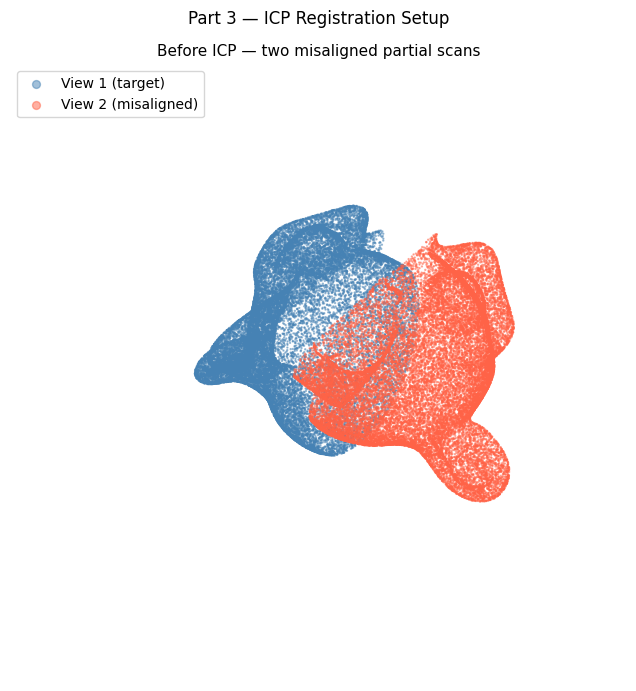

In [9]:
# ── Create two partial views from the uniform cloud ──────────────────────────
pts_all  = np.asarray(pcd_uniform.points)
median_x = np.median(pts_all[:, 0])
overlap  = 0.08          # overlap region so ICP has shared geometry to match

mask1 = pts_all[:, 0] < (median_x + overlap)
mask2 = pts_all[:, 0] > (median_x - overlap)

pcd_view1 = pcd_uniform.select_by_index(np.where(mask1)[0])
pcd_view2 = pcd_uniform.select_by_index(np.where(mask2)[0])

# ── Apply a KNOWN misalignment to View 2 ─────────────────────────────────────
# (ICP will try to recover this)
angle_deg  = 25.0
angle_rad  = np.radians(angle_deg)

R_true = np.array([[ np.cos(angle_rad), 0, np.sin(angle_rad)],
                   [ 0,                 1, 0                 ],
                   [-np.sin(angle_rad), 0, np.cos(angle_rad) ]])

t_true = np.array([0.25, 0.05, 0.10])

T_true        = np.eye(4)
T_true[:3, :3] = R_true
T_true[:3, 3]  = t_true

pcd_view2_misaligned = o3d.geometry.PointCloud(pcd_view2)
pcd_view2_misaligned.transform(T_true)

print(f"View 1 (target) : {len(pcd_view1.points):,} pts")
print(f"View 2 (source) : {len(pcd_view2_misaligned.points):,} pts  "
      f"[misaligned by {angle_deg:.0f}° + t={t_true}]")

# ── Visualise the misalignment ────────────────────────────────────────────────
pts1 = np.asarray(pcd_view1.points)
pts2 = np.asarray(pcd_view2_misaligned.points)

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')
ax.scatter(pts1[:, 0], pts1[:, 1], pts1[:, 2],
           c='steelblue', s=0.5, alpha=0.5, label='View 1 (target)')
ax.scatter(pts2[:, 0], pts2[:, 1], pts2[:, 2],
           c='tomato',    s=0.5, alpha=0.5, label='View 2 (misaligned)')
ax.set_title('Before ICP — two misaligned partial scans', fontsize=11)
ax.set_axis_off()
ax.legend(markerscale=8, loc='upper left')
plt.suptitle('Part 3 — ICP Registration Setup', fontsize=12)
plt.tight_layout()
plt.show()


### 3.1  Apply ICP  *(TODO)*

Open3D's ICP API:

```python
result = o3d.pipelines.registration.registration_icp(
    source,                        # cloud to transform  →  pcd_view2_misaligned
    target,                        # reference cloud     →  pcd_view1
    max_correspondence_distance,   # max allowed point-pair distance (try 0.05 – 0.1)
    init,                          # initial 4×4 guess (np.eye(4) = no prior)
    estimation_method,             # TransformationEstimationPointToPoint()
    criteria                       # ICPConvergenceCriteria(max_iteration=...)
)
```

Key output fields:

| Field | Meaning |
|-------|---------|
| `result.transformation` | Estimated 4×4 transformation T |
| `result.fitness` | Fraction of points with a close match (1.0 = perfect) |
| `result.inlier_rmse` | RMS distance of matched point pairs (lower = better) |

**Suggested steps:**
1. Set `max_correspondence_distance = 0.05`
2. Use `init = np.eye(4)` (start with identity — no prior guess)
3. Set `max_iteration = 100` in `ICPConvergenceCriteria`
4. Print `fitness` and `inlier_rmse`
5. Compare `result.transformation` to `T_true` (the ground truth)


In [10]:
# ── TODO 1: Run ICP ──────────────────────────────────────────────────────────
#
# Fill in the arguments below.
# Hint: estimation_method = o3d.pipelines.registration.TransformationEstimationPointToPoint()
#       criteria          = o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=100)

threshold       = ...   # max correspondence distance  (try 0.05)
init_transform  = ...   # initial guess — 4×4 numpy array  (try np.eye(4))

reg_result = o3d.pipelines.registration.registration_icp(
    ...,   # source
    ...,   # target
    ...,   # threshold
    ...,   # init_transform
    ...,   # estimation_method
    ...,   # criteria
)

print(f"ICP fitness     : {reg_result.fitness:.4f}   (1.0 = perfect)")
print(f"ICP inlier RMSE : {reg_result.inlier_rmse:.6f}")
print(f"\nEstimated T:\n{reg_result.transformation.round(4)}")
print(f"\nGround-truth T:\n{T_true.round(4)}")


TypeError: registration_icp(): incompatible function arguments. The following argument types are supported:
    1. (source: open3d.cpu.pybind.geometry.PointCloud, target: open3d.cpu.pybind.geometry.PointCloud, max_correspondence_distance: float, init: numpy.ndarray[numpy.float64[4, 4]] = array([[1., 0., 0., 0.], [0., 1., 0., 0.], [0., 0., 1., 0.], [0., 0., 0., 1.]]), estimation_method: open3d.cpu.pybind.pipelines.registration.TransformationEstimation = TransformationEstimationPointToPoint(with_scaling=False), criteria: open3d.cpu.pybind.pipelines.registration.ICPConvergenceCriteria = ICPConvergenceCriteria(relative_fitness=1.000000e-06, relative_rmse=1.000000e-06, max_iteration=30)) -> open3d.cpu.pybind.pipelines.registration.RegistrationResult

Invoked with: Ellipsis, Ellipsis, Ellipsis, Ellipsis, Ellipsis, Ellipsis

### 3.2  Visualise the Result  *(TODO)*

Apply the estimated transformation to the misaligned View 2 and plot both clouds
on the same axes to verify the alignment visually.

```python
pcd_aligned = o3d.geometry.PointCloud(pcd_view2_misaligned)
pcd_aligned.transform(reg_result.transformation)
```

Then scatter-plot `pcd_view1` in blue and `pcd_aligned` in orange.
If ICP converged correctly, the two clouds should overlap almost perfectly.


In [ ]:
# ── TODO 2: Visualise alignment ───────────────────────────────────────────────
#
# 1. Create a copy of pcd_view2_misaligned
# 2. Apply reg_result.transformation to the copy
# 3. Scatter-plot View 1 (blue) and the aligned View 2 (orange) on the same axes

# YOUR CODE HERE


### 3.3  Error Analysis  *(TODO)*

Compare the estimated transformation to the ground truth `T_true`.

**Rotation error:**

```python
R_est  = reg_result.transformation[:3, :3]
R_diff = R_est.T @ R_true                        # should be close to identity
angle_error = np.degrees(np.arccos(
    np.clip((np.trace(R_diff) - 1) / 2, -1, 1)))
```

**Translation error:**

```python
t_est   = reg_result.transformation[:3, 3]
t_error = np.linalg.norm(t_est - t_true)
```

Print both errors. A well-converged ICP should give rotation error < 2° and
translation error < 0.01 for this setup.


In [ ]:
# ── TODO 3: Error analysis ────────────────────────────────────────────────────
#
# Compute rotation error (degrees) and translation error (L2 distance)
# between reg_result.transformation and T_true.

# YOUR CODE HERE


### 3.4  Experiment — What Happens with a Bad Initial Guess?  *(optional)*

ICP is a **local** optimiser — it only finds the nearest local minimum.
If the initial misalignment is too large, it can get stuck.

Try re-running ICP with:
- A **larger rotation** (e.g. 90°) and `init = np.eye(4)`
- Then try again with `init = T_true` (perfect prior) — ICP should then converge easily

This demonstrates why **global registration** methods (e.g. Fast Global Registration,
or feature-based initialisation with FPFH descriptors) are used to provide a good
starting point before running ICP for fine alignment.


In [ ]:
# ── Optional experiment ───────────────────────────────────────────────────────
#
# 1. Create a new large misalignment (e.g. 90° rotation around Y)
# 2. Run ICP with init = np.eye(4)  → observe poor fitness
# 3. Run ICP with init = T_large    → observe good fitness

# YOUR CODE HERE


---
## Summary

| Stage | Tool | Key Parameter |
|-------|------|--------------|
| Mesh → Point Cloud | `sample_points_uniformly` | `number_of_points` |
| Outlier Removal | `remove_statistical_outlier` | `nb_neighbors`, `std_ratio` |
| Downsampling | `voxel_down_sample` | `voxel_size` |
| Normal Estimation | `estimate_normals` | `radius`, `max_nn` |
| Surface Reconstruction | `create_from_point_cloud_poisson` | `depth` |
| **Registration** | **`registration_icp`** | **`max_correspondence_distance`**, **`init`** |

### Connection to the SfM Pipeline

```
Multiple images
    └─► Feature matching (SIFT / SuperPoint)
            └─► Sparse 3D cloud  (Eight-point + Triangulation)
                    └─► Dense cloud  (MVS / depth fusion)
                            └─► ICP registration  ◄── THIS LAB
                                    └─► Poisson mesh  ◄── ALSO THIS LAB
                                            └─► Robot task planning
```

ICP sits at the junction between per-view reconstruction and global map building —
the exact problem being tackled by AI-enhanced SfM systems for robotic perception.
